<a href="https://colab.research.google.com/github/arunreghunath25b-afk/Unsupervised_CaseStudy_arun/blob/main/Unsupervised_CaseStudy_Arun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DSA/Case study/adult_dataset.csv')

In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [5]:
df.shape

(48842, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [8]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,45480,48842,48842,45485,48842,48842,48842,46137,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,32220,15784,22379,5854,19716,41762,32650,41622,24720


In [9]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [10]:
(df == '?').sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [11]:
df = df.replace('?', np.nan)

In [12]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [13]:
numeric_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [15]:
df.duplicated().sum()

np.int64(17)

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(48825, 15)

In [18]:
income_profile = df['income'].copy()

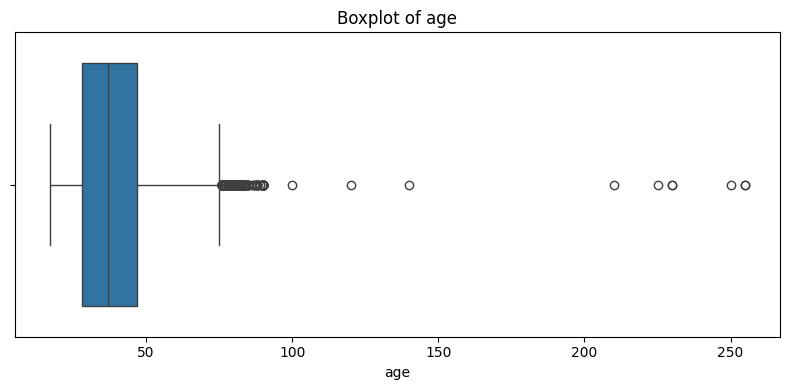

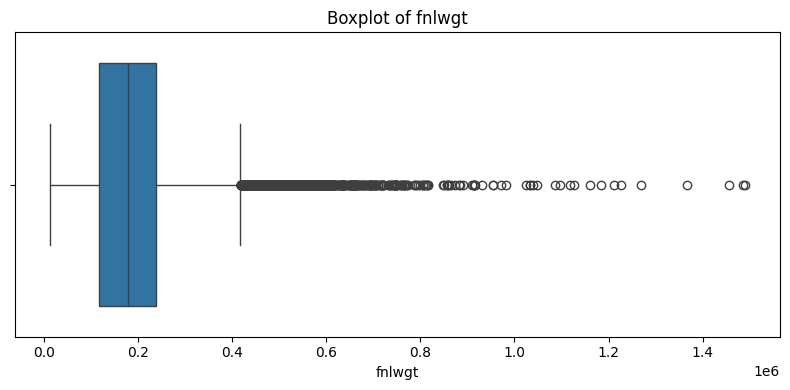

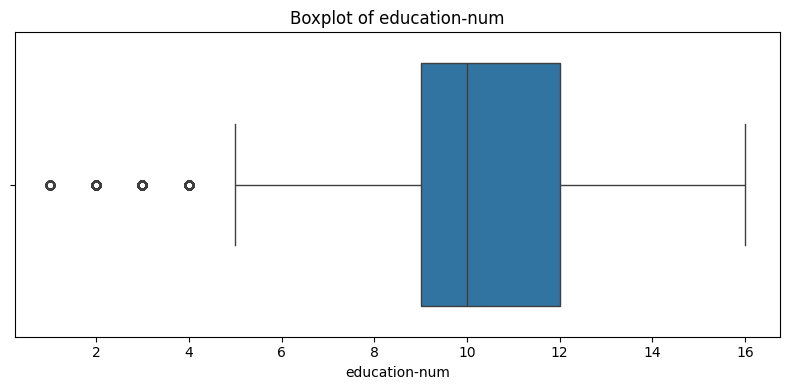

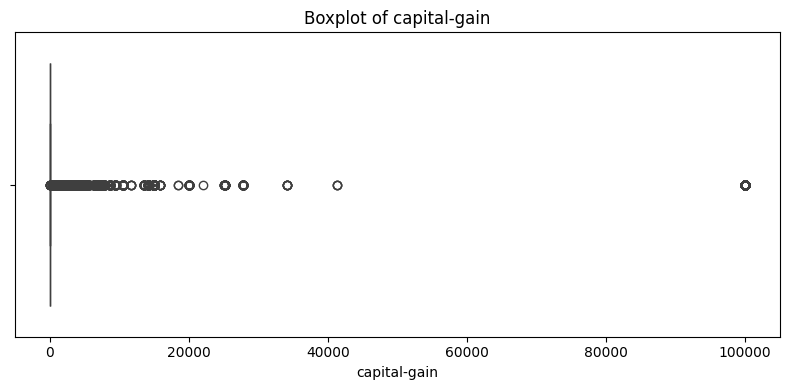

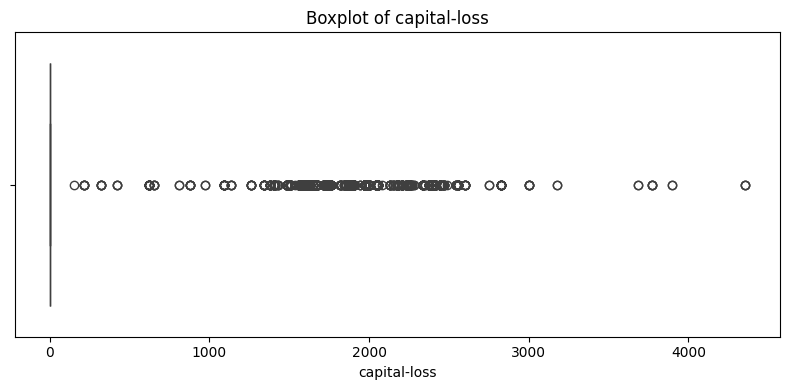

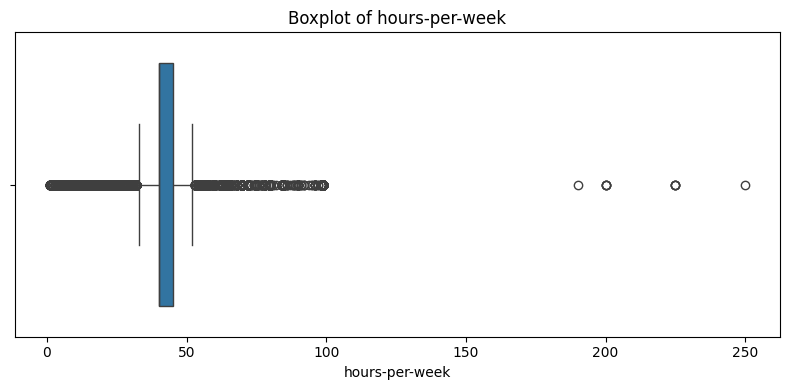

In [19]:
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [20]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

age : 363
fnlwgt : 1453
education-num : 1791
capital-gain : 4035
capital-loss : 2282
hours-per-week : 12833


In [21]:
outlier_cols = [
    'age',
    'fnlwgt',
    'hours-per-week'
]

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

In [63]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = encoder.fit_transform(
    df[categorical_cols]
)

In [25]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)

In [26]:
df_encoded = df.drop(
    columns=categorical_cols
)

In [27]:
df_encoded = pd.concat(
    [df_encoded, encoded_df],
    axis=1
)

In [28]:
df_encoded.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,39.0,77516.0,13,2174,0,40.0,<=50K,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,50.0,83311.0,13,0,0,32.5,<=50K,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38.0,215646.0,9,0,0,40.0,<=50K,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,53.0,234721.0,7,0,0,40.0,<=50K,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,28.0,338409.0,13,0,0,40.0,<=50K,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
income_profile = df_encoded['income'].copy()

X = df_encoded.drop(
    columns=['income']
)

In [30]:
print("X shape:", X.shape)

X shape: (48825, 108)


In [31]:
X = df_encoded.drop(columns=['income'])

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,39.0,77516.0,13,2174,0,40.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,50.0,83311.0,13,0,0,32.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38.0,215646.0,9,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,53.0,234721.0,7,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,28.0,338409.0,13,0,0,40.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
X.dtypes.value_counts()

,count
float64,105
int64,3


In [35]:
X.isnull().sum().sum()

np.int64(0)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (48825, 108)


In [37]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,0.035120,-1.146130,1.136553,0.146857,-0.217167,-0.187372,-0.168373,-0.254635,-0.013578,-1.391959,...,-0.059976,-0.020243,-0.046645,-0.035368,-0.024378,-0.022634,-2.401294,-0.041266,-0.021709,3.738582
1,0.864053,-1.085334,1.136553,-0.144829,-0.217167,-1.430403,-0.168373,-0.254635,-0.013578,-1.391959,...,-0.059976,-0.020243,-0.046645,-0.035368,-0.024378,-0.022634,0.416442,-0.041266,-0.021709,-0.267481
2,-0.040238,0.303010,-0.419528,-0.144829,-0.217167,-0.187372,-0.168373,-0.254635,-0.013578,0.718412,...,-0.059976,-0.020243,-0.046645,-0.035368,-0.024378,-0.022634,0.416442,-0.041266,-0.021709,-0.267481
3,1.090126,0.503128,-1.197569,-0.144829,-0.217167,-0.187372,-0.168373,-0.254635,-0.013578,0.718412,...,-0.059976,-0.020243,-0.046645,-0.035368,-0.024378,-0.022634,0.416442,-0.041266,-0.021709,-0.267481
4,-0.793814,1.590932,1.136553,-0.144829,-0.217167,-0.187372,-0.168373,-0.254635,-0.013578,0.718412,...,-0.059976,-0.020243,-0.046645,-0.035368,-0.024378,-0.022634,-2.401294,-0.041266,-0.021709,-0.267481


In [38]:
X_scaled_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
count,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,...,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04,4.882500e+04
mean,-2.290618e-16,-1.324309e-16,3.366073e-16,-6.839838e-18,4.249431e-17,-3.652764e-16,-2.910569e-18,-5.093496e-18,-2.037399e-18,-1.172232e-16,...,1.542602e-17,7.276423e-18,-1.891870e-18,4.947968e-18,1.164228e-18,5.675610e-18,8.891789e-17,4.365854e-18,3.347155e-18,-5.500976e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,...,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622747e+00,-1.830477e+00,-3.531691e+00,-1.448293e-01,-2.171667e-01,-1.430403e+00,-1.683727e-01,-2.546351e-01,-1.357814e-02,-1.391959e+00,...,-5.997601e-02,-2.024337e-02,-4.664486e-02,-3.536839e-02,-2.437849e-02,-2.263394e-02,-2.401294e+00,-4.126552e-02,-2.170926e-02,-2.674811e-01
25%,-7.938136e-01,-7.260755e-01,-4.195285e-01,-1.448293e-01,-2.171667e-01,-1.873724e-01,-1.683727e-01,-2.546351e-01,-1.357814e-02,-1.391959e+00,...,-5.997601e-02,-2.024337e-02,-4.664486e-02,-3.536839e-02,-2.437849e-02,-2.263394e-02,4.164421e-01,-4.126552e-02,-2.170926e-02,-2.674811e-01
50%,-1.155954e-01,-9.050193e-02,-3.050812e-02,-1.448293e-01,-2.171667e-01,-1.873724e-01,-1.683727e-01,-2.546351e-01,-1.357814e-02,7.184121e-01,...,-5.997601e-02,-2.024337e-02,-4.664486e-02,-3.536839e-02,-2.437849e-02,-2.263394e-02,4.164421e-01,-4.126552e-02,-2.170926e-02,-2.674811e-01
75%,6.379804e-01,5.335419e-01,7.475326e-01,-1.448293e-01,-2.171667e-01,6.413149e-01,-1.683727e-01,-2.546351e-01,-1.357814e-02,7.184121e-01,...,-5.997601e-02,-2.024337e-02,-4.664486e-02,-3.536839e-02,-2.437849e-02,-2.263394e-02,4.164421e-01,-4.126552e-02,-2.170926e-02,-2.674811e-01
max,2.785671e+00,2.422968e+00,2.303614e+00,1.327207e+01,1.058996e+01,1.884346e+00,5.939204e+00,3.927188e+00,7.364781e+01,7.184121e-01,...,1.667333e+01,4.939889e+01,2.143859e+01,2.827384e+01,4.101976e+01,4.418144e+01,4.164421e-01,2.423330e+01,4.606328e+01,3.738582e+00


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (48825, 108)
PCA shape: (48825, 2)


In [39]:
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

PC1: 0.04298684431728019
PC2: 0.028050046711971123
Total: 0.07103689102925131


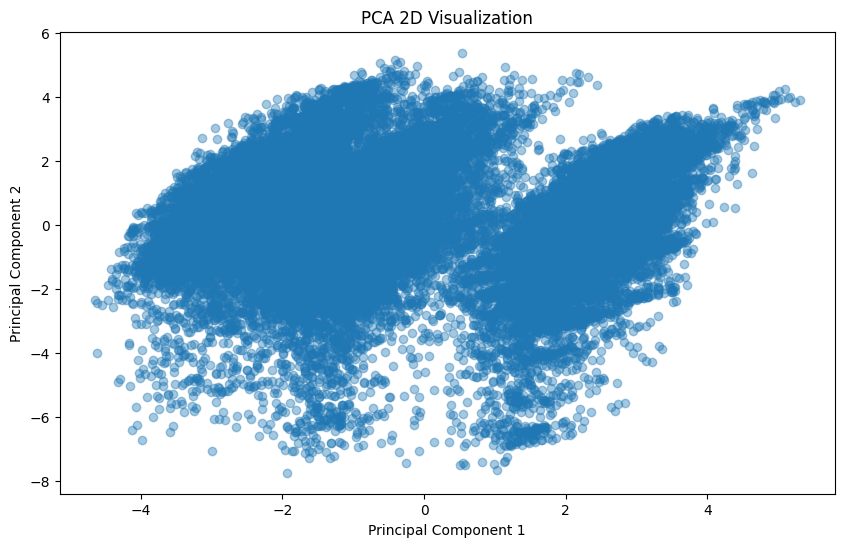

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.4
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA 2D Visualization')

plt.show()

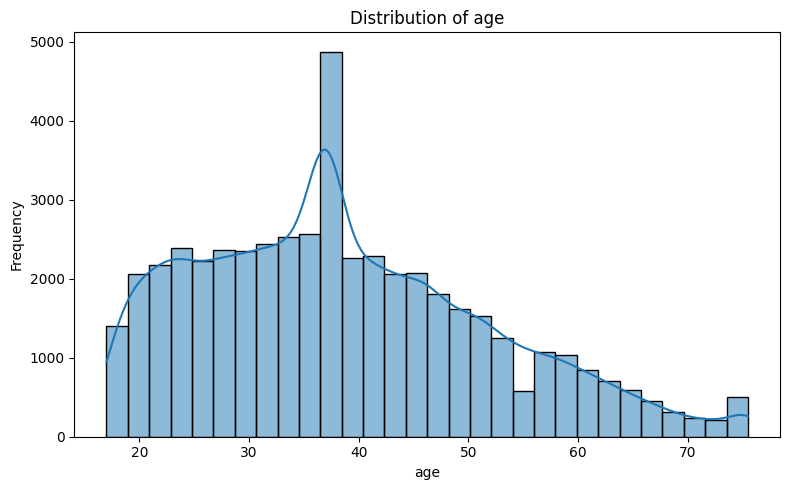

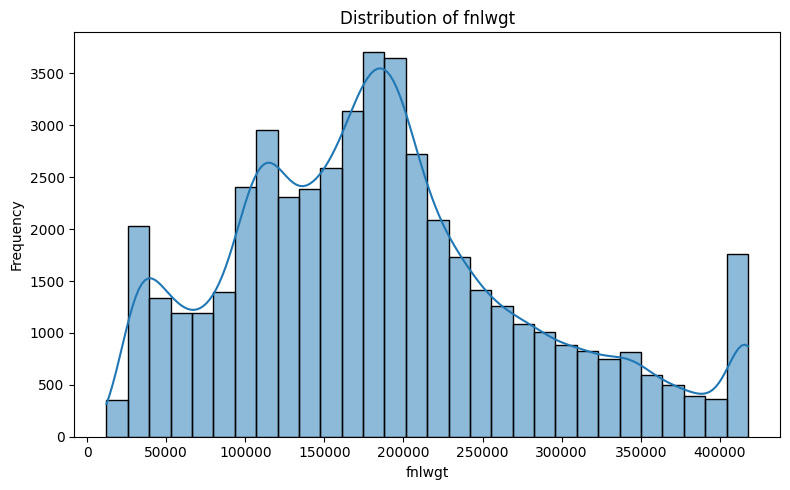

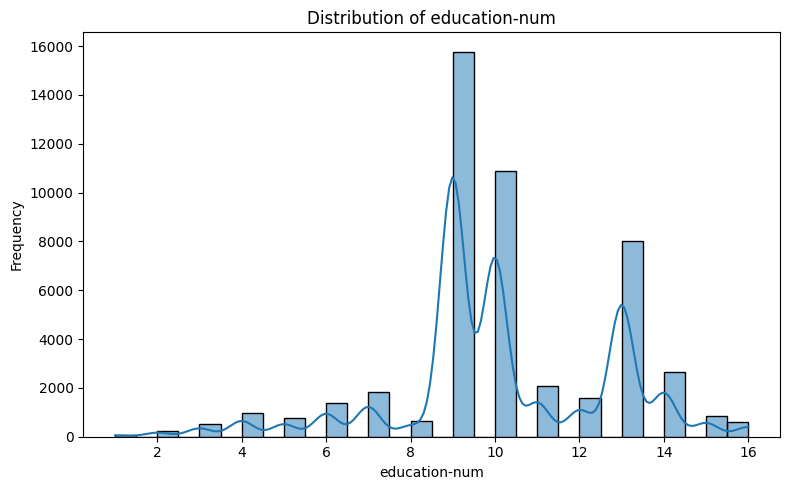

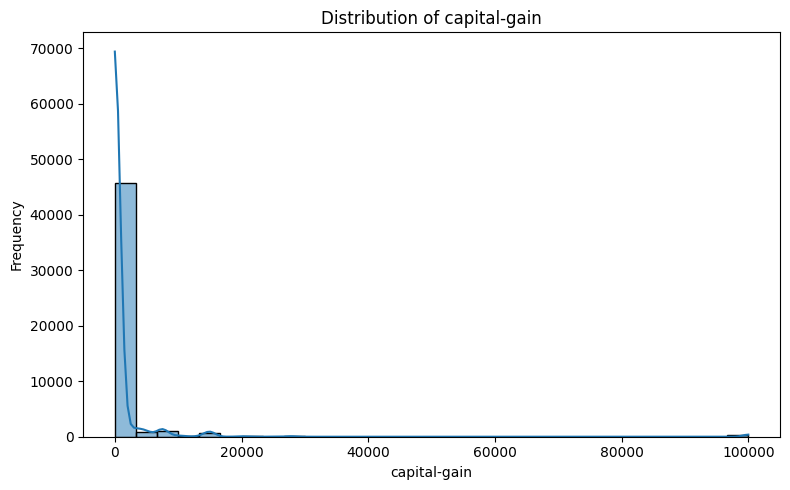

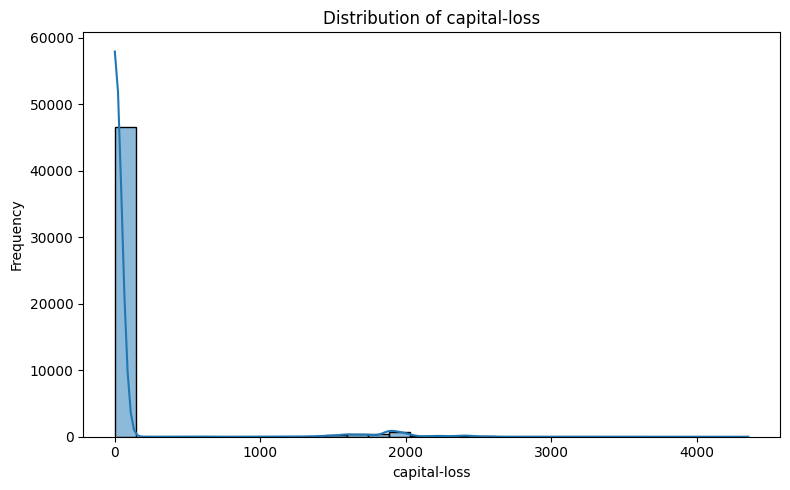

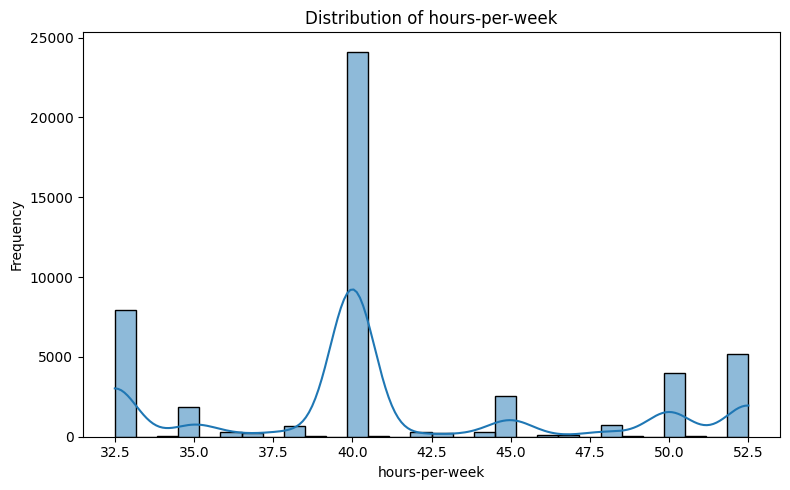

In [41]:
numeric_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]
for col in numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

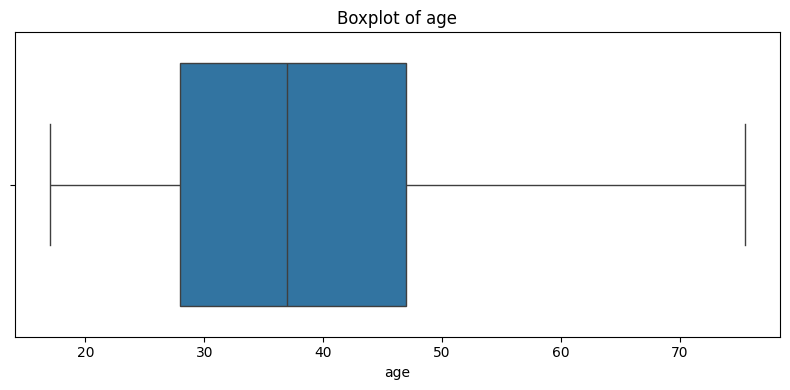

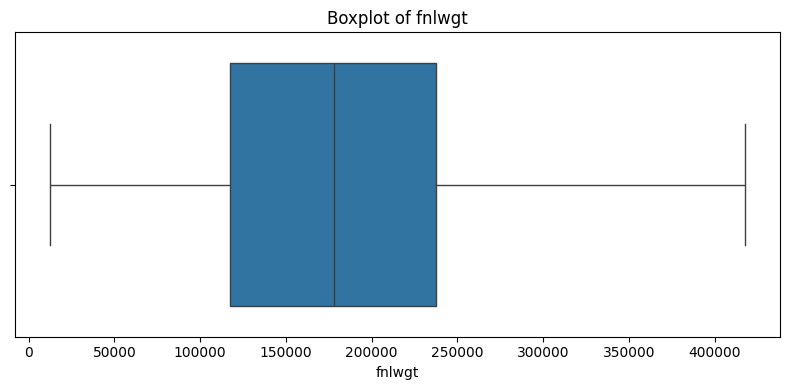

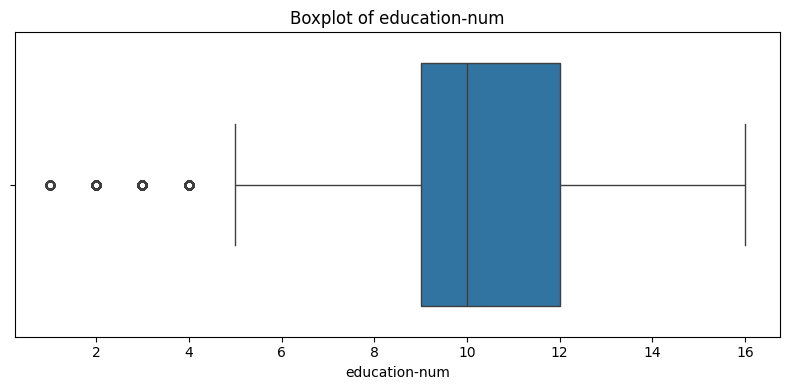

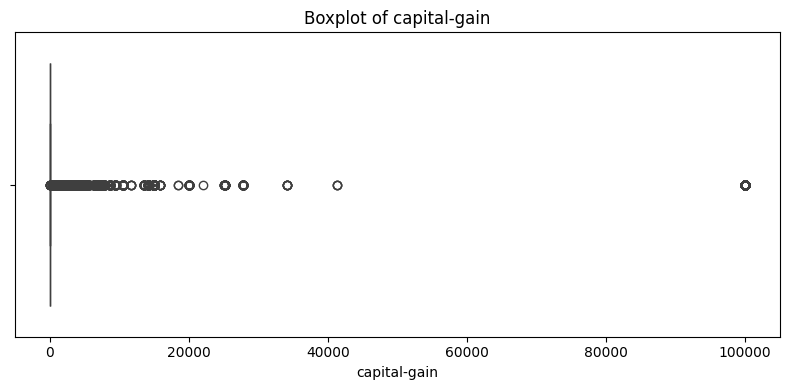

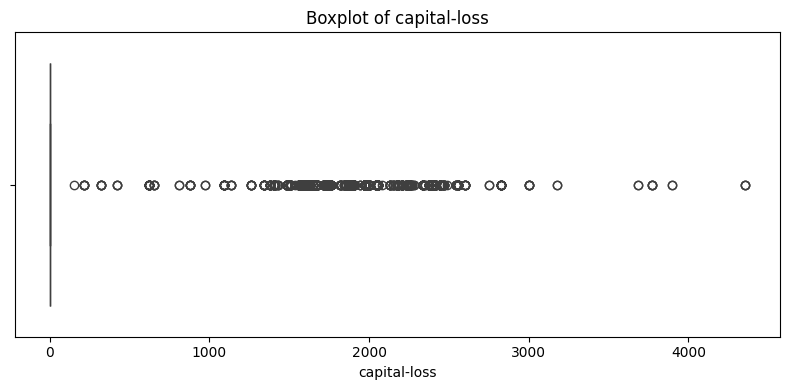

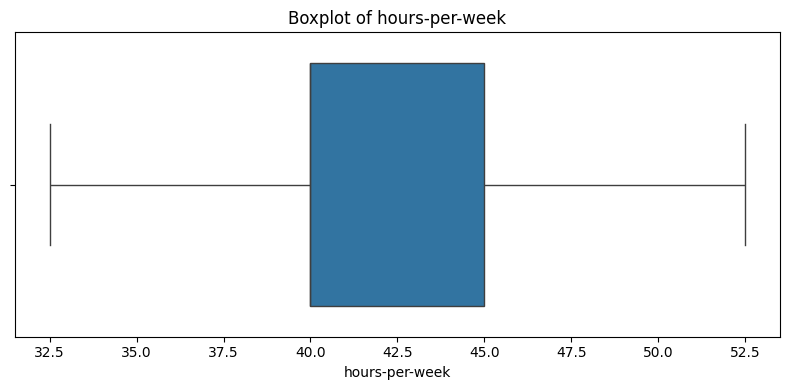

In [42]:
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

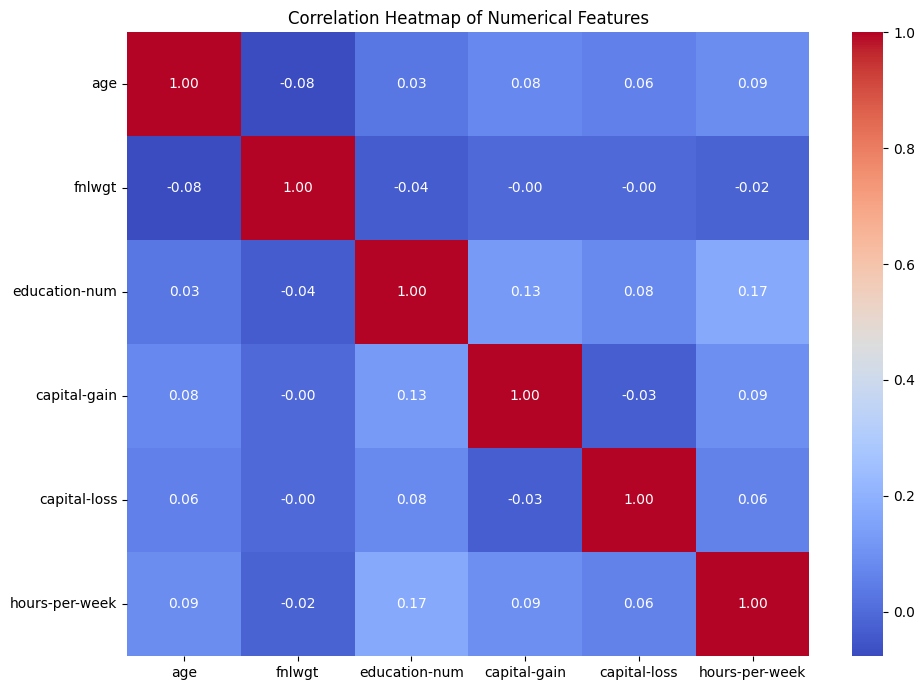

In [43]:
# Correlation matrix for numerical features

plt.figure(figsize=(10, 7))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [44]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

print(wcss)

[4937743.245900474, 4848014.474053712, 4792722.650041819, 4727606.364060488, 4671279.208489178, 4615259.210635276, 4557291.659792569, 4498936.994427644, 4453684.960109584]


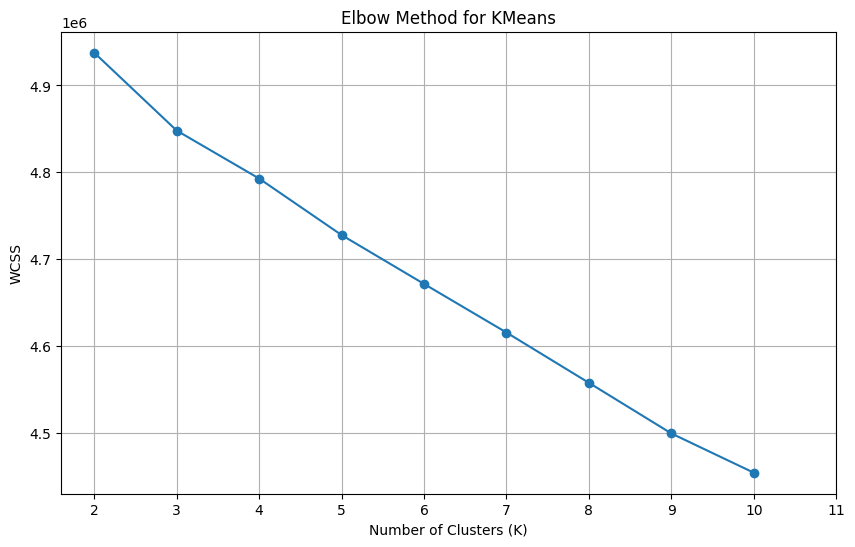

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for KMeans')

plt.xticks(range(2, 12))
plt.grid()

plt.show()

In [46]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0577
K = 3, Silhouette Score = 0.0556
K = 4, Silhouette Score = 0.0577
K = 5, Silhouette Score = 0.0559
K = 6, Silhouette Score = 0.0533
K = 7, Silhouette Score = 0.0581
K = 8, Silhouette Score = 0.0419
K = 9, Silhouette Score = 0.0390
K = 10, Silhouette Score = 0.0634


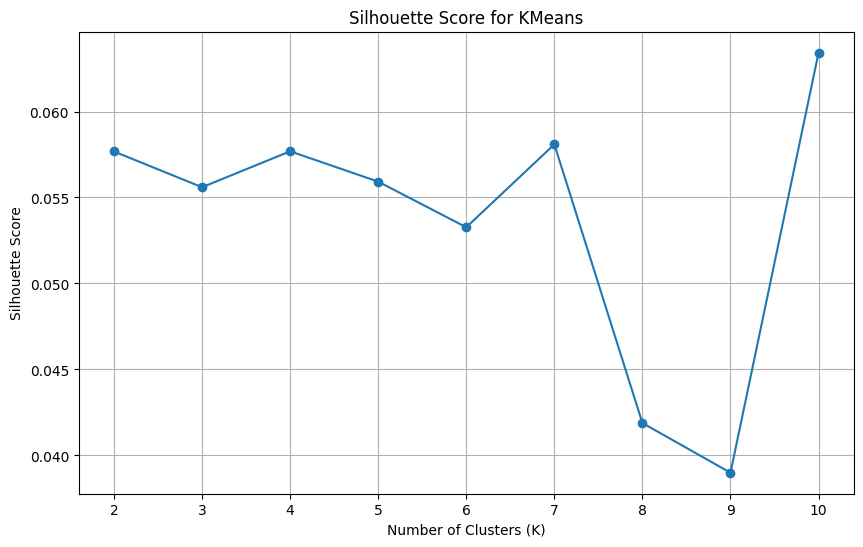

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")

plt.xticks(range(2, 11))
plt.grid()

plt.show()

In [48]:
from sklearn.cluster import KMeans

optimal_k = 10

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("KMeans completed successfully")
print("Number of clusters:", len(np.unique(kmeans_labels)))

KMeans completed successfully
Number of clusters: 10


In [49]:
df['KMeans_Cluster'] = kmeans_labels

df['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,194
1,6886
2,15746
3,2206
4,6775
5,3511
6,2589
7,9476
8,1320


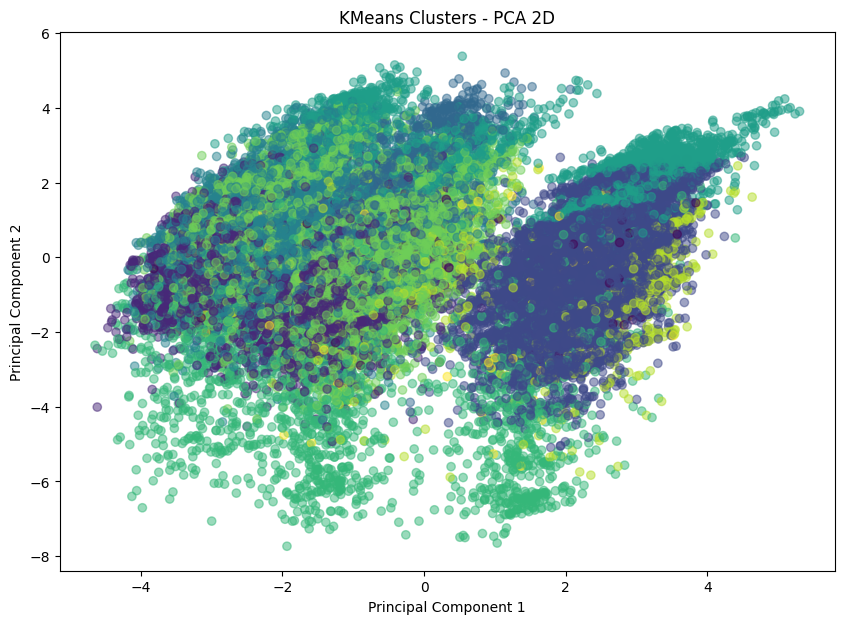

In [50]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters - PCA 2D")

plt.show()

In [41]:
# Take 5000 samples
X_agg = X_scaled[:5000]

print("Agglomerative data shape:", X_agg.shape)

Agglomerative data shape: (5000, 108)


In [43]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=10)

agg_labels = agg.fit_predict(X_agg)

print("Agglomerative clustering completed")
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative clustering completed
0    2470
1    1922
2      78
3     464
4       4
5      15
6      25
7      10
8       9
9       3
Name: count, dtype: int64


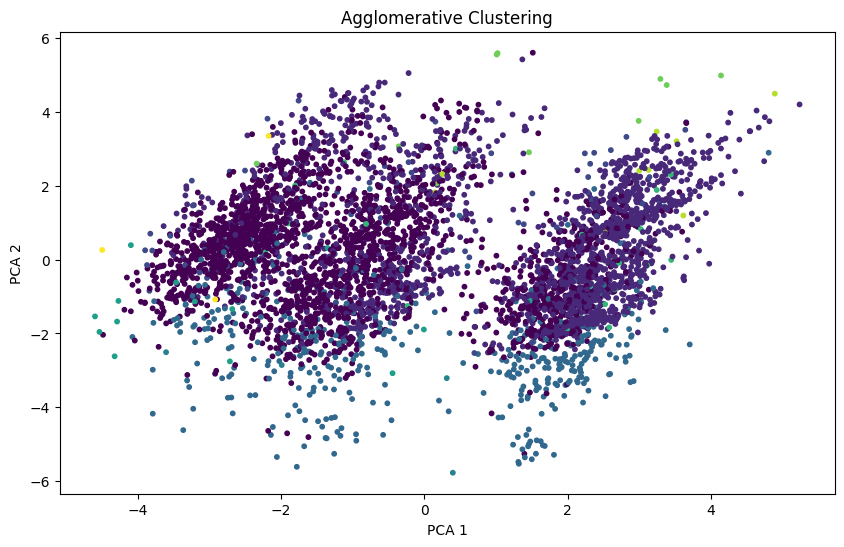

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_agg = PCA(n_components=2)

X_agg_pca = pca_agg.fit_transform(X_agg)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_agg_pca[:, 0],
    X_agg_pca[:, 1],
    c=agg_labels,
    s=10
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Agglomerative Clustering")
plt.show()

In [47]:
# Create dataframe for the 5000 sampled records
agg_df = df.iloc[:5000].copy()

# Add Agglomerative cluster labels
agg_df['Agg_Cluster'] = agg_labels

# Numerical cluster profile
profile = agg_df.groupby('Agg_Cluster')[
    ['age', 'education-num', 'capital-gain',
     'capital-loss', 'hours-per-week']
].mean()

profile.round(2)

,age,education-num,capital-gain,capital-loss,hours-per-week
Agg_Cluster,,,,,
0,35.80,10.08,372.79,50.19,39.90
1,41.52,11.01,1925.75,153.17,43.26
2,35.41,11.32,1646.64,213.56,40.88
3,41.06,5.87,576.78,68.79,39.98
4,44.00,8.00,0.00,0.00,36.25
5,32.00,9.87,0.00,0.00,39.33
6,39.78,10.96,508.04,0.00,40.60
7,41.20,13.00,3004.40,156.40,42.75
8,33.56,13.11,11921.89,0.00,46.94


In [49]:
income_profile = pd.crosstab(
    agg_df['Agg_Cluster'],
    agg_df['income'],
    normalize='index'
) * 100

income_profile.round(2)

income,<=50K,>50K
Agg_Cluster,,
0,84.45,15.55
1,61.08,38.92
2,74.36,25.64
3,90.73,9.27
4,100.00,0.00
5,80.00,20.00
6,60.00,40.00
7,30.00,70.00
8,33.33,66.67


In [50]:
from sklearn.metrics import silhouette_score

agg_silhouette = silhouette_score(X_agg, agg_labels)

print("Agglomerative Silhouette Score:",
      round(agg_silhouette, 4))

Agglomerative Silhouette Score: 0.0133


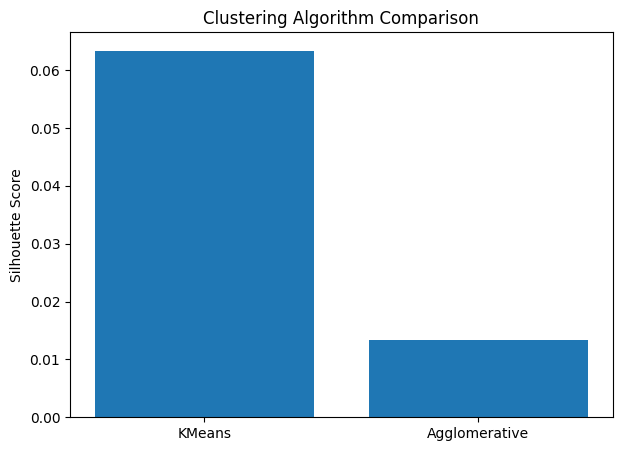

In [52]:
import matplotlib.pyplot as plt

methods = ['KMeans', 'Agglomerative']
scores = [0.0634, 0.0133]

plt.figure(figsize=(7, 5))
plt.bar(methods, scores)

plt.ylabel('Silhouette Score')
plt.title('Clustering Algorithm Comparison')

plt.show()

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Final clustering comparison
comparison = pd.DataFrame({
    'Algorithm': ['KMeans', 'Agglomerative'],
    'Clusters': [10, 10],
    'Silhouette Score': [0.0634, 0.0133]
})

print(comparison)

       Algorithm  Clusters  Silhouette Score
0         KMeans        10            0.0634
1  Agglomerative        10            0.0133


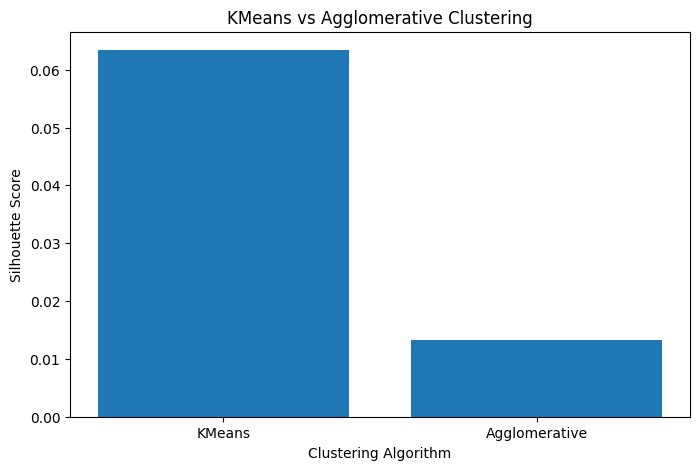

In [57]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Algorithm'],
    comparison['Silhouette Score']
)

plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.title('KMeans vs Agglomerative Clustering')

plt.show()

In [59]:
print("FINAL CLUSTERING RESULTS")
print("-" * 35)

print("KMeans:")
print("  Number of clusters:", 10)
print("  Silhouette Score:", 0.0634)

print("\nAgglomerative:")
print("  Number of clusters:", 10)
print("  Silhouette Score:", 0.0133)

FINAL CLUSTERING RESULTS
-----------------------------------
KMeans:
  Number of clusters: 10
  Silhouette Score: 0.0634

Agglomerative:
  Number of clusters: 10
  Silhouette Score: 0.0133


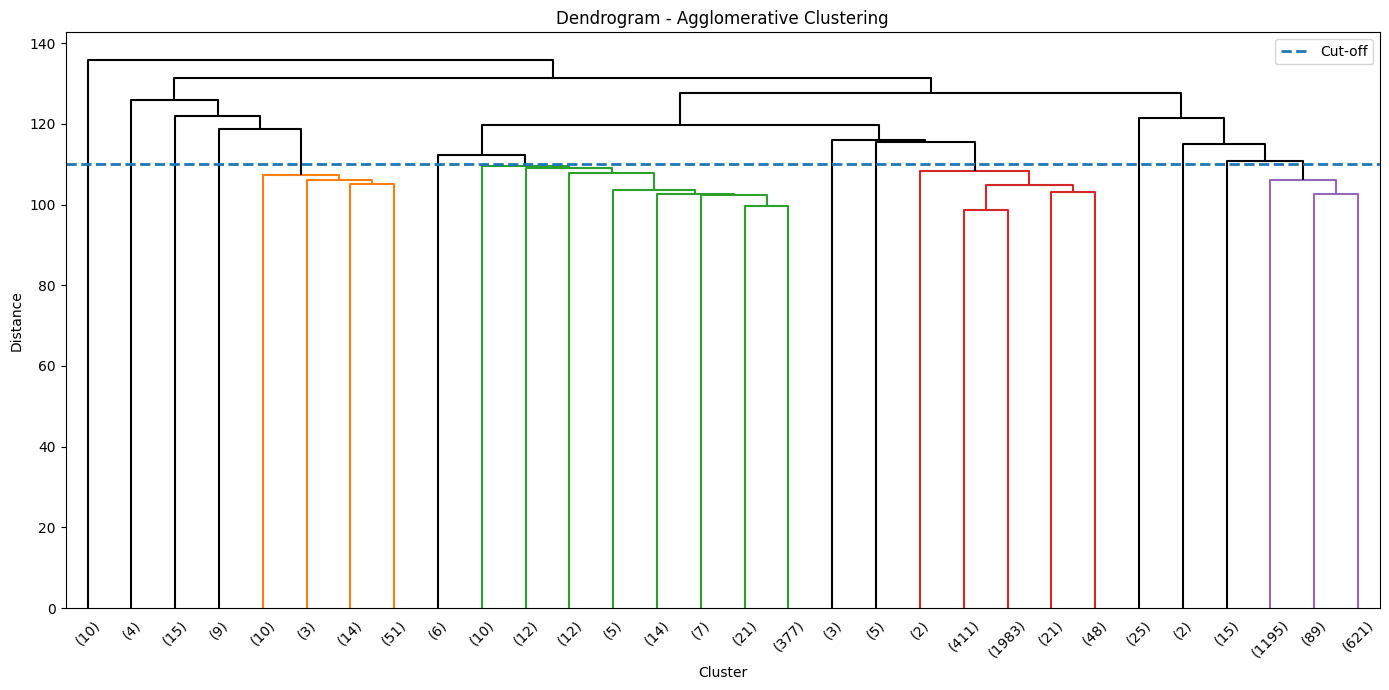

In [64]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Same 5000 samples
X_dendro = X_scaled[:5000]

# Ward linkage
Z = linkage(X_dendro, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    color_threshold=110,   # controls branch colors
    above_threshold_color='black',
    show_leaf_counts=True
)

plt.axhline(
    y=110,
    linestyle='--',
    linewidth=2,
    label='Cut-off'
)

plt.title('Dendrogram - Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex'
]

categorical_profile = pd.DataFrame()

for col in categorical_cols:
    categorical_profile[col] = agg_df.groupby('Agg_Cluster')[col].agg(
        lambda x: x.mode().iloc[0]
    )

categorical_profile

,workclass,education,marital-status,occupation,relationship,race,sex
Agg_Cluster,,,,,,,
0,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,White,Male
1,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male
2,Private,Bachelors,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male
3,Private,10th,Married-civ-spouse,Craft-repair,Husband,White,Male
4,Private,12th,Married-civ-spouse,Machine-op-inspct,Husband,Black,Female
5,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,Black,Female
6,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male
7,Private,Doctorate,Married-civ-spouse,Prof-specialty,Husband,White,Male
8,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male


In [68]:
final_profile = profile.copy()

for col in categorical_profile.columns:
    final_profile[col] = categorical_profile[col]

final_profile

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex
Agg_Cluster,,,,,,,,,,,,
0,35.803239,10.076518,372.791903,50.185830,39.895547,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,White,Male
1,41.517950,11.014048,1925.754422,153.165453,43.258585,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male
2,35.410256,11.320513,1646.641026,213.564103,40.878205,Private,Bachelors,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male
3,41.060345,5.866379,576.778017,68.790948,39.983836,Private,10th,Married-civ-spouse,Craft-repair,Husband,White,Male
4,44.000000,8.000000,0.000000,0.000000,36.250000,Private,12th,Married-civ-spouse,Machine-op-inspct,Husband,Black,Female
5,32.000000,9.866667,0.000000,0.000000,39.333333,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,Black,Female
6,39.780000,10.960000,508.040000,0.000000,40.600000,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male
7,41.200000,13.000000,3004.400000,156.400000,42.750000,Private,Doctorate,Married-civ-spouse,Prof-specialty,Husband,White,Male
8,33.555556,13.111111,11921.888889,0.000000,46.944444,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male


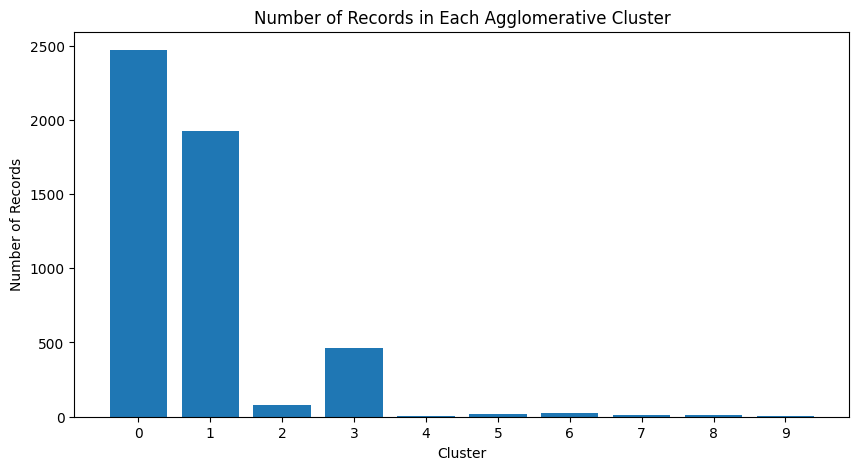

In [72]:
import matplotlib.pyplot as plt

cluster_counts = agg_df['Agg_Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Records')
plt.title('Number of Records in Each Agglomerative Cluster')

plt.show()

In [73]:
# ==========================================
# FINAL FINDINGS - ADULT CENSUS DATASET
# ==========================================

print("=" * 60)
print("FINAL FINDINGS - UNSUPERVISED LEARNING")
print("=" * 60)

# 1. KMeans
print("\n1. KMEANS")
print("-" * 40)
print("Number of clusters: 10")
print("Silhouette Score: 0.0634")

# 2. Agglomerative
print("\n2. AGGLOMERATIVE CLUSTERING")
print("-" * 40)
print("Number of clusters: 10")
print("Sample size: 5000")
print("Silhouette Score: 0.0133")

# 3. Cluster sizes
print("\n3. CLUSTER SIZES")
print("-" * 40)
print(cluster_counts)

# 4. Numerical findings
print("\n4. NUMERICAL FINDINGS")
print("-" * 40)

print(
    "Highest average age: Cluster",
    profile['age'].idxmax(),
    "=", round(profile['age'].max(), 2)
)

print(
    "Highest education: Cluster",
    profile['education-num'].idxmax(),
    "=", round(profile['education-num'].max(), 2)
)

print(
    "Highest working hours: Cluster",
    profile['hours-per-week'].idxmax(),
    "=", round(profile['hours-per-week'].max(), 2)
)

print(
    "Highest capital gain: Cluster",
    profile['capital-gain'].idxmax(),
    "=", round(profile['capital-gain'].max(), 2)
)

# 5. Income findings
print("\n5. INCOME FINDINGS")
print("-" * 40)

print(income_profile.round(2))

print(
    "\nHighest >50K income proportion:",
    "Cluster",
    income_profile['>50K'].idxmax(),
    "=",
    round(income_profile['>50K'].max(), 2),
    "%"
)

print("=" * 60)
print("FINAL ANALYSIS COMPLETED")
print("=" * 60)

FINAL FINDINGS - UNSUPERVISED LEARNING

1. KMEANS
----------------------------------------
Number of clusters: 10
Silhouette Score: 0.0634

2. AGGLOMERATIVE CLUSTERING
----------------------------------------
Number of clusters: 10
Sample size: 5000
Silhouette Score: 0.0133

3. CLUSTER SIZES
----------------------------------------
Agg_Cluster
0    2470
1    1922
2      78
3     464
4       4
5      15
6      25
7      10
8       9
9       3
Name: count, dtype: int64

4. NUMERICAL FINDINGS
----------------------------------------
Highest average age: Cluster 4 = 44.0
Highest education: Cluster 8 = 13.11
Highest working hours: Cluster 8 = 46.94
Highest capital gain: Cluster 8 = 11921.89

5. INCOME FINDINGS
----------------------------------------
income        <=50K   >50K
Agg_Cluster               
0             84.45  15.55
1             61.08  38.92
2             74.36  25.64
3             90.73   9.27
4            100.00   0.00
5             80.00  20.00
6             60.00  40.00
7